# Forecast Model Comparison Review

This notebook compares the completed monthly forecasting models using their persisted validation and test predictions. The comparison is deliberately performed after model training so the saved forecasts can be inspected without refitting or changing any model.

The comparison includes the seasonal benchmark, Random Forest, ANN, and LSTM using the same persisted validation and test forecasts.






## Comparison protocol

All models are compared on the same 24-month validation window and the same untouched 36-month test window. Metrics are recomputed from persisted predictions, and the plots show both forecast levels and residual behaviour.






In [11]:
from pathlib import Path
import json
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.forecasting_evaluation import load_phase5_artifacts
from src.evaluation.model_comparison import (
    build_comparison_tables,
    load_saved_predictions,
    save_comparison_outputs,
)

predictions = load_saved_predictions(PROJECT_ROOT)
tables = build_comparison_tables(PROJECT_ROOT)
print('Models included:', list(predictions))
print('Validation forecast rows:', len(next(iter(predictions.values()))['validation']))
print('Test forecast rows:', len(next(iter(predictions.values()))['test']))






Models included: ['Seasonal naive', 'Random Forest', 'ANN', 'LSTM']
Validation forecast rows: 24
Test forecast rows: 36


## Recomputed scorecards

The tables below are generated from the persisted forecasts and provide a common basis for model ranking. Lower MAE, RMSE, and sMAPE are preferable; higher R-squared is preferable.






In [12]:
display(tables['metrics'].round(3))
display(tables['rankings'].round(3))






,model,split,mae,rmse,mape,smape,r2
0,ANN,test,375856.590,450990.485,9.510,9.013,0.609
1,LSTM,test,404871.042,497991.624,9.541,9.696,0.523
2,Seasonal naive,test,433726.936,526201.042,9.915,10.559,0.467
3,Random Forest,test,486348.093,584281.741,11.454,11.838,0.343
4,ANN,validation,227344.522,284796.500,5.921,5.770,0.797
5,LSTM,validation,255569.662,289081.453,6.548,6.558,0.791
6,Random Forest,validation,286119.370,345121.157,7.105,7.345,0.702
7,Seasonal naive,validation,291879.192,357628.720,7.278,7.533,0.680


,model,split,mae,rmse,mape,smape,r2,rmse_rank,mae_rank
0,ANN,test,375856.590,450990.485,9.510,9.013,0.609,1.0,1.0
1,LSTM,test,404871.042,497991.624,9.541,9.696,0.523,2.0,2.0
2,Seasonal naive,test,433726.936,526201.042,9.915,10.559,0.467,3.0,3.0
3,Random Forest,test,486348.093,584281.741,11.454,11.838,0.343,4.0,4.0
4,ANN,validation,227344.522,284796.500,5.921,5.770,0.797,1.0,1.0
5,LSTM,validation,255569.662,289081.453,6.548,6.558,0.791,2.0,2.0
6,Random Forest,validation,286119.370,345121.157,7.105,7.345,0.702,3.0,3.0
7,Seasonal naive,validation,291879.192,357628.720,7.278,7.533,0.680,4.0,4.0


In [13]:
display(tables['residuals'].round(3))






,model,split,mean_residual,residual_std,residual_mae,residual_rmse,max_absolute_residual
0,ANN,test,-175618.221,415392.174,375856.590,450990.485,917071.119
1,LSTM,test,159729.881,471680.001,404871.042,497991.624,1102886.000
2,Seasonal naive,test,368900.492,375233.213,433726.936,526201.042,1276016.700
3,Random Forest,test,289689.490,507410.241,486348.093,584281.741,1239251.844
4,ANN,validation,-60404.231,278317.041,227344.522,284796.500,633124.806
5,LSTM,validation,61047.987,282561.905,255569.662,289081.453,568952.800
6,Random Forest,validation,167325.614,301845.576,286119.370,345121.157,749287.124
7,Seasonal naive,validation,175864.467,311400.050,291879.192,357628.720,752276.000


## Forecast and residual diagnostics

The comparison outputs include actual-versus-forecast plots for both windows and residual plots for error direction, spread, and outliers.






In [14]:
saved_paths = save_comparison_outputs(PROJECT_ROOT)
coverage = json.loads((PROJECT_ROOT / 'outputs' / 'metrics' / 'phase5_model_comparison_coverage.json').read_text())
print('Saved comparison outputs:')
print(saved_paths)
print('Coverage:')
print(coverage)






Saved comparison outputs:
{'metrics': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/phase5_model_comparison_metrics.csv'), 'residuals': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/phase5_model_comparison_residuals.csv'), 'rankings': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/phase5_model_comparison_rankings.csv'), 'coverage': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/phase5_model_comparison_coverage.json'), 'residual_figure': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/figures/model_comparison/02_residual_comparison.png'), 'validation_figure': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/figures/model_comparison/01_validation_forecast_comparison.png'), 'test_figure': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/figures/model_comparison/01_test_forecast_comparison.png')}
Coverage:
{'included_models': ['Seasonal naive',

## Interpretation

The comparison identifies the strongest completed model on each split, but the results remain a synthetic-data benchmark. All four completed models are compared using the same chronology-safe persisted prediction workflow.






## Visual model comparison



These charts place the four forecasts against the observed demand trajectory and show the corresponding residual patterns for both chronological evaluation windows.





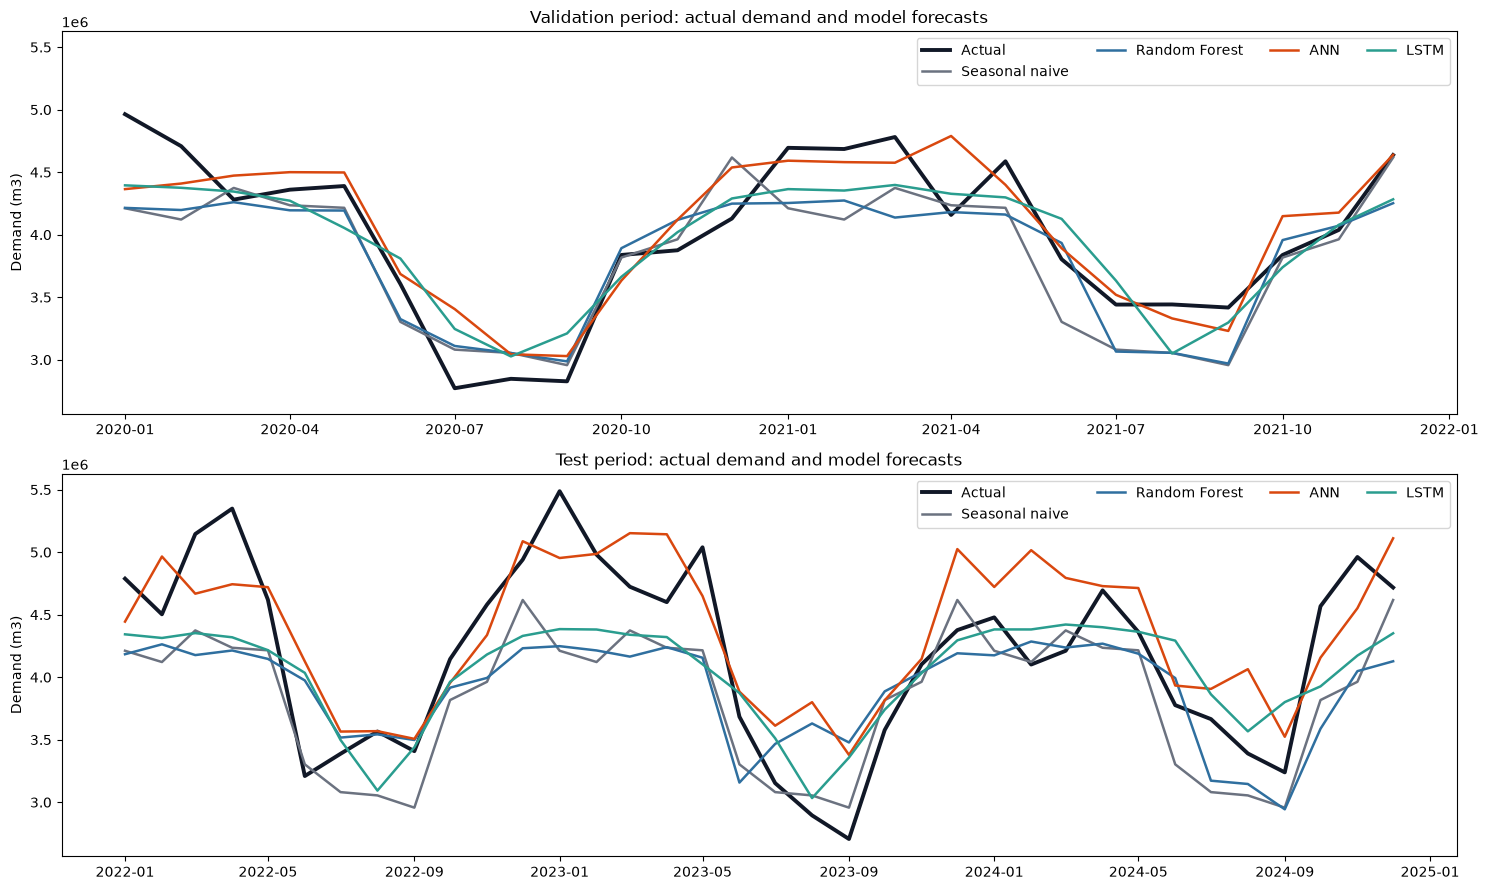

In [15]:
import matplotlib.pyplot as plt

model_colors = {'Seasonal naive': '#6b7280', 'Random Forest': '#2f6f9f', 'ANN': '#d9480f', 'LSTM': '#2a9d8f'}
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharey=True)
for axis, split in zip(axes, ('validation', 'test')):
    actual = load_phase5_artifacts(PROJECT_ROOT)[f'{split}_y']
    axis.plot(actual.index, actual.values, color='#111827', linewidth=2.8, label='Actual')
    for model_name, split_predictions in predictions.items():
        axis.plot(split_predictions[split].index, split_predictions[split].values, linewidth=1.8, color=model_colors[model_name], label=model_name)
    axis.set_title(f'{split.title()} period: actual demand and model forecasts')
    axis.set_ylabel('Demand (m3)')
    axis.legend(ncol=4)
fig.tight_layout()
plt.show()






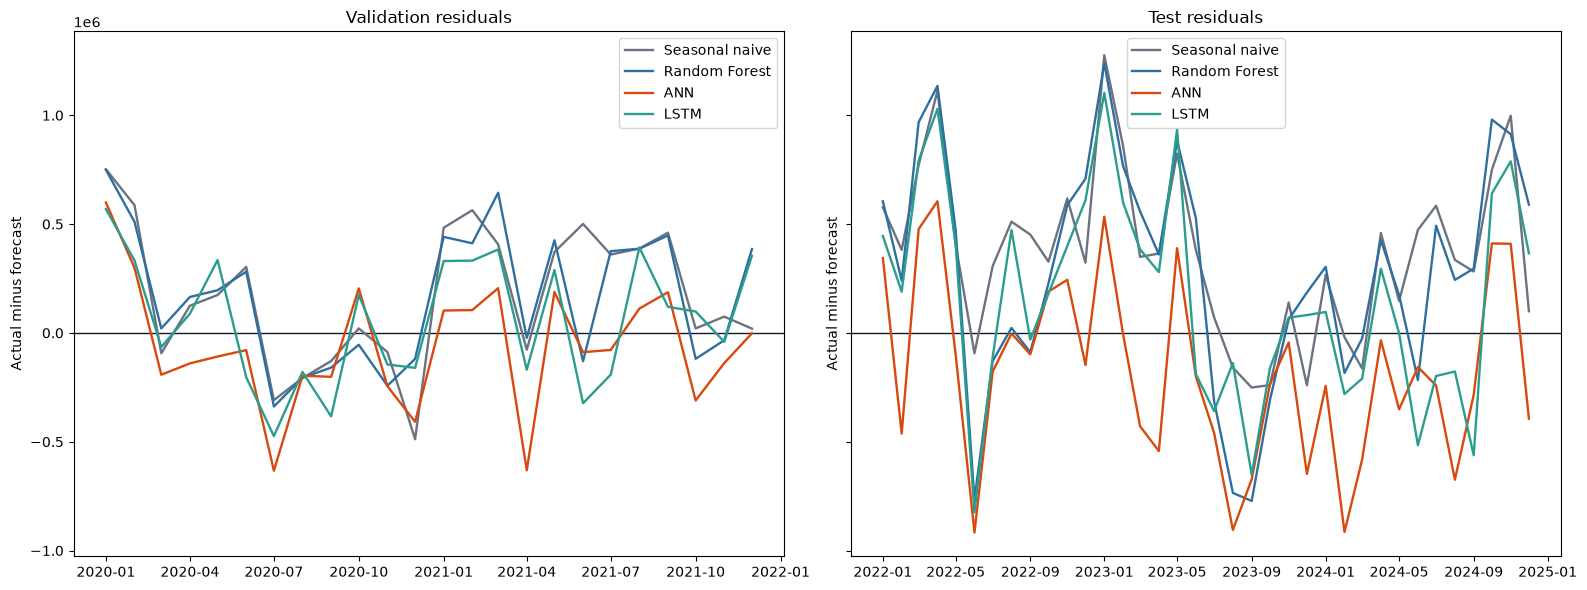

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for axis, split in zip(axes, ('validation', 'test')):
    actual = load_phase5_artifacts(PROJECT_ROOT)[f'{split}_y']
    axis.axhline(0, color='#111827', linewidth=1)
    for model_name, split_predictions in predictions.items():
        residual = actual - split_predictions[split]
        axis.plot(residual.index, residual.values, linewidth=1.7, color=model_colors[model_name], label=model_name)
    axis.set_title(f'{split.title()} residuals')
    axis.set_ylabel('Actual minus forecast')
    axis.legend()
fig.tight_layout()
plt.show()




